# 들어가며

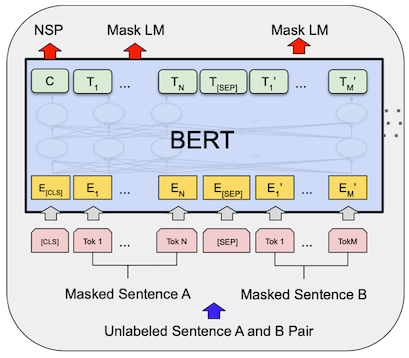

지난 시간 우리는 transformer 기반의 pretrained model의 발전사를 살펴보고, 어떻게 이 모델들이 맥락 기반의 word representation을 구성할 수 있으며 또한 Transfer learning을 통해 다양한 자연어 처리 문제를 쉽게 해결할 수 있는지 살펴보았습니다.

이런 모델들을 만들어 내기 위해서는 아주 큰 사이즈의 모델이 필요합니다. 가장 대표적인 BERT만 하더라도 정식 모델은 340M나 되는 파라미터 사이즈를 자랑합니다. 이들을 수십 GB나 되는 코퍼스를 토대로 학습시키는 것은 최고 성능의 GPU를 가지고도 수일 내지 수 주일의 시간이 걸립니다. 아마도 여러분 대부분의 학습환경에서 이를 수행하는 것은 가능한 일이 아닐 것입니다.

그래서 오늘은 일반적인 10M 정도의 작은 파라미터 사이즈의 BERT 모델을 만들어, 수백 MB 수준의 코퍼스 기반으로 pretrain 을 진행해 보도록 하겠습니다. 하지만 진행되는 과정은 정식 BERT와 동일할 테니 이를 토대로 pretrained model이 어떻게 만들어지는지를 경험해 보도록 합시다. 모델을 만들고 학습시키는 것 이상으로 코퍼스 데이터를 가공해서 학습시켜야 할 task에 적합한 형태의 데이터셋으로 만들어가는 것이 큰 비중을 차지한다는 것을 알게 될 것입니다.

오늘의 작업을 위해 다음과 같이 작업환경을 마련해 주세요. 학습에 사용할 코퍼스 데이터를 아래에 첨부해 두었습니다.

**[아이스브레이킹] NLP 모델들은 세서미 스트리트(Sesame street) 등장인물들의 이름을 따서 지었는데요, 여러분들만의 모델 이름은 뭐가 좋을까요?** \
A. [ 답변을 적어볼까요! ] \

\

<details>
<summary>💡예시답안 확인하기💡</summary>

A. 주요 인물 이름은 거의 다 쓰였어요😭 얼른 서둘러야겠어요! 여러분들의 힘을 보여주세요!

</details>

[kowiki.txt.zip](https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip)

## 데이터 다운로드
---

```
$ mkdir -p ~/aiffel/bert_pretrain/data
$ mkdir -p ~/aiffel/bert_pretrain/models
$ wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
$ mv kowiki.txt.zip ~/aiffel/bert_pretrain/data
$ cd ~/aiffel/bert_pretrain/data && unzip kowiki.txt.zip
```

혹시 이번 실습에서 필요한 아래 라이브러리가 없다면 미리 설치해 주세요.


```
$ pip install sentencepiece
$ pip install tqdm
$ conda install -c conda-forge ipywidgets
$ jupyter nbextension enable --py widgetsnbextension
```

In [ ]:
!mkdir data
!mkdir models

In [ ]:
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip

--2026-07-14 15:16:04--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 3.165.160.100, 3.165.160.93, 3.165.160.58, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.165.160.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M  29.0MB/s    in 8.8s    

2026-07-14 15:16:13 (26.4 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]



In [ ]:
!mv kowiki.txt.zip /content/data

In [ ]:
%cd /content/data
!unzip kowiki.txt.zip

/content/data
Archive:  kowiki.txt.zip
  inflating: kowiki.txt              


In [ ]:
!pip install sentencepiece
!pip install tqdm
!conda install -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension

/bin/bash: line 1: conda: command not found
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


## 학습 내용
---
  - 2. Tokenizer 준비
    - BPE를 바탕으로 단어를 분석해봐요.
  - 3. 데이터 전처리 (1) MASK 생성
    - Masked LM은 어떻게 만들까요?
  - 4. 데이터 전처리 (2) NSP pair 생성
    - 다음에 이어질 문장으로 가장 적절한 것을 고르시오.
  - 5. 데이터 전처리 (3) 데이터셋 완성
    - NSP에 맞게 데이터셋도 다시 만들어봐요.
  - 6. BERT 모델 구현
    - 나만의 작고 소중한 BERT
  - 7. pretrain 진행
    - 그 유명한 pretrained model, 제가 한 번 만들어 볼게요.

## 학습 목표
---
- BERT 모델을 구현하고 훈련시킬 수 있다.
- BERT에 사용된 masking 기법들을 이해하고 구현할 수 있다.
- NSP task를 이해하고, 데이터셋을 이에 맞게 구성할 수 있다.

# Tokenizer 준비

BERT등의 pretrained model이 나오게 되었을 즈음 자연어처리 분야의 또 다른 중요한 흐름 중 하나는 BPE 등의 subword 기반의 토크나이징 기법이 주요한 방법론으로 굳어졌다는 점입니다. GPT의 BPE, BERT의 WordPiece 모델 등의 성공이 더욱 사람들에게 subword 기반의 토크나이저에 대한 확신을 주었습니다.

오늘 우리는 [SentencePiece](https://github.com/google/sentencepiece) 기반의 토크나이저를 준비하는 것으로 BERT pretrain 과정을 시작할 것입니다. 이 과정 자체는 이미 익숙하실 것이라 생각합니다.

In [ ]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.11.0+cu128


준비해 둔 한글 나무위키 코퍼스로부터 32000의 vocab_size를 갖는 sentencepiece 모델을 생성해 보겠습니다.

BERT에 사용되는 `[MASK]`, `[SEP]`, `[CLS]` 등의 주요 특수문자가 vocab에 포함되어야 함에 주의해 주세요. 아래와 같이 모델을 생성하게 되면 약 30분 정도가 소요될 것입니다. **그래서 아래 코드는 보기만하고 넘어가고 미리 만들어 놓은 파일을 아래 처럼 따라하여 사용하겠습니다.**

(선택) 직접 model 과 vocab 을 만들기 : cloud shell을 열어 아래 코드를 한줄씩 실행해주세요.



```
$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = os.getenv('HOME')+'/aiffel/bert_pretrain/data/kowiki.txt'
>>> prefix = os.getenv('HOME')+'/aiffel/bert_pretrain/models/ko_32000'
>>> vocab_size = 32000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
```

SentencePieceTrainer 에 전달하는 파라미터 설명은 [setencepiece/doc/options.md](https://github.com/google/sentencepiece/blob/master/doc/options.md) 를 확인하세요.


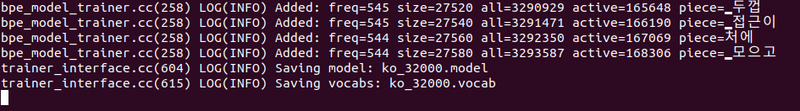

> 이미지와 같이 터미널에서 `ko_32000.model`, `ko_32000.vocab` 생성을 확인할 수 있습니다.

sentencepiece 모델 학습이 끝난 후 생성된 `ko_32000.model`, `ko_32000.vocab` 두 파일은 커널이 생성되었을 때의 홈 디렉토리에 생성되었을 것입니다. 이 두 파일을 `~/aiffel/bert_pretrain/models` 아래로 이동시킨 후 계속 진행해 주세요.



```
# 홈 디렉토리에서 아래 명령어를 입력해 주세요.
$ mv ko_32000.* ~/aiffel/bert_pretrain/models
```



In [ ]:
import sentencepiece as spm
import os
corpus_file = '/content/data/kowiki.txt'
prefix = '/content/models/ko_32000'
vocab_size = 32000
spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")

In [ ]:
data_dir = '/content/data'
model_dir = '/content/models'

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_32000.model")

True

토크나이저가 잘 만들어졌는지 확인해 봅시다. 어떤 토큰이 만들어졌는지, 토크나이징 결과가 어떻게 나오는지 살펴볼까요?

In [ ]:
#Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁의', '▁오', '▁마', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁구', '▁세', '▁도', '▁상', '▁비', '▁스', '▁국', '▁서', '▁후', '▁여', '▁200', '▁때', '▁4', '▁성', '▁해', '▁관', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁(', '▁역', '되어', '▁않', '▁만', '▁"', '▁장', '▁바', '까지', '▁무', '▁남', '▁통', '▁현', '▁교', '▁같', '에게', '▁내', '학교', '▁문', '▁출', '▁거', '▁포', '▁결', '된다', '▁《', '적인', '이라', '▁6', '▁우', '적으로', '▁불', '▁원', '▁최', '▁진', '▁생', '▁작', '▁어', '▁당', '국의', '▁노', '▁강', '▁알', '▁반', '▁7', '▁8', '▁계', '▁따', '▁파', '▁분', '▁없', '▁받', '▁말', '면서', '들이', 'or', '되었', '▁사용', "▁'", '▁두', '▁실', '에서는', '▁10', '▁리', '들은', '▁명', '▁함', '▁단', '▁이후', '하기', '▁예', '년에', '),',

In [ ]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


토크나이저가 잘 작동하나요? 방금 우리는 SentencePiece 모델을 이용해 간단한 BERT의 Masked Language Model 학습용 데이터를 하나 생성해 보았습니다.

다음 절부터 본격적으로 데이터 전처리 과정에 돌입하겠습니다.

# 데이터 전처리 (1) MASK 생성

BERT의 Masked Language Model(MLM)은 GPT의 Next Token Prediction 태스크처럼 `다음이 이어질 단어는?` 을 맞추는 게 아니라 마스킹 된 `다음 빈칸에 알맞은 단어는?` 문제를 푸는 형식으로 구성됩니다.

MLM을 위해 BERT는 학습 데이터의 전체에서 15%를 `[MASK]` 토큰으로 랜덤하게 바꿉니다. 이 15%의 `[MASK]` 토큰 중 80%는 `[MASK]` 토큰, 10%는 무작위로 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용합니다.

이전 스텝의 Masked LM 데이터셋 예시에서 출발해 봅시다.

In [ ]:
print(tokens_org)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)
mask_cnt

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


10

15%를 마스킹 한다고 해도 생각해 볼 것이 더 있습니다. Subword 기반으로 토크나이징을 했을 때 `_대, [MASK], 민국`이라고 가운데를 마스킹 했을 경우 해당 `[MASK]`가 '한'일 거라는 건 너무 쉽게 맞출 수 있습니다. '대한민국'이라는 패턴을 아주 자주 보게 될 테니까요.

그래서 Masked LM 태스크를 구성할 땐 **띄어쓰기 단위로 한꺼번에 마스킹**해 주는 것이 좋습니다. 다음과 같이 처리합니다.

In [ ]:
# 띄어쓰기 단위로 mask하기 위해서 index 분할
cand_idx = []  # word 단위의 index array
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # u"\u2581"는 단어의 시작을 의미하는 값
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])

# 결과확인
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

[1, 2, 3] ['▁추적', '추', '적']
[4] ['▁비가']
[5] ['▁내리는']
[6, 7, 8] ['▁날', '이었', '어']
[9, 10] ['▁그날', '은']
[11, 12, 13] ['▁', '왠', '지']
[14, 15] ['▁손', '님이']
[16] ['▁많아']
[17] ['▁첫']
[18] ['▁번에']
[19, 20] ['▁삼', '십']
[21] ['▁전']
[22, 23] ['▁둘째', '번']
[24, 25] ['▁오', '십']
[26] ['▁전']
[27, 28] ['▁오랜', '만에']
[29, 30] ['▁받아', '보는']
[31] ['▁십']
[32, 33] ['▁전', '짜리']
[34, 35, 36] ['▁백', '통', '화']
[37, 38, 39] ['▁서', '푼', '에']
[41] ['▁손바닥']
[42, 43] ['▁위', '엔']
[44, 45] ['▁기쁨', '의']
[46, 47] ['▁눈', '물이']
[48] ['▁흘러']
[49, 50, 51] ['▁컬', '컬', '한']
[52] ['▁목에']
[53, 54] ['▁모', '주']
[55, 56, 57] ['▁한', '잔', '을']
[58, 59] ['▁적', '셔']
[60] ['▁몇']
[61] ['▁달']
[62] ['▁포']
[63] ['▁전부터']
[64, 65, 66] ['▁콜', '록', '거리는']
[67] ['▁아내']
[68] ['▁생각에']
[69, 70] ['▁그', '토록']
[71] ['▁먹고']
[72, 73] ['▁싶다', '던']


In [ ]:
# random mask를 위해서 index 순서를 섞음
random.shuffle(cand_idx)
cand_idx

[[18],
 [44, 45],
 [24, 25],
 [49, 50, 51],
 [31],
 [63],
 [41],
 [52],
 [22, 23],
 [71],
 [17],
 [19, 20],
 [60],
 [32, 33],
 [62],
 [46, 47],
 [29, 30],
 [72, 73],
 [6, 7, 8],
 [64, 65, 66],
 [67],
 [9, 10],
 [26],
 [55, 56, 57],
 [61],
 [34, 35, 36],
 [37, 38, 39],
 [21],
 [58, 59],
 [48],
 [69, 70],
 [4],
 [27, 28],
 [42, 43],
 [14, 15],
 [68],
 [5],
 [11, 12, 13],
 [1, 2, 3],
 [16],
 [53, 54]]

개선된 Masking 로직을 다음과 같이 구현해 보았습니다. 마스킹 된 결과를 이전과 비교해 보시죠.

In [ ]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 핸재 mask된 개수가 15%를 넘으면 중지
          break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
          continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9: # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁불규칙', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘러', '[MASK]', '[MASK]', '[MASK]', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


Masked LM의 라벨 데이터도 아래와 같이 생성하여 정리해 둡니다.

In [ ]:
# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

mask_idx   : [18, 24, 25, 31, 44, 45, 49, 50, 51, 63]
mask_label : ['▁번에', '▁오', '십', '▁십', '▁기쁨', '의', '▁컬', '컬', '한', '▁전부터']


## 🔶 create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.

In [ ]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

`create_pretrain_mask()` 수행 결과를 다시 한번 확인해 봅시다.

In [ ]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '[MASK]', '[MASK]', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '[MASK]', '▁컬', '컬', '한', '[MASK]', '끊', '쇼에서', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '[MASK]', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

mask_idx   : [16, 17, 37, 38,

# 데이터 전처리 (2) NSP pair 생성

BERT의 pretrain task로 Next Sentence Prediction이 있습니다. 문장 2개를 붙여 놓고 두 문장이 이어지는 것인지 아닌지 문장 호응관계를 맞출 수 있게 하는 것입니다.

아래와 같이 문장 A의 다음 문장이 B일 경우는 `TRUE`, 아니면 `FALSE`로 예측하게 합니다.


```
[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 그 사람이 바다의 뚜껑 닫지 않고 돌아가[SEP] → TRUE(IsNext)

[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 한강에서 자전거 타며 아이스아메리카노를 마시고 싶다[SEP] → FALSE(NotNext)
```
아래 문장을 예시로 진행해 보겠습니다.

In [ ]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [ ]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'],
 ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'],
 ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

우선 원문에서 이어진 두 문장씩 짝지어 보겠습니다.

이 단계에서 넣어줄 특수 token은 `[CLS]`와 `[SEP]`이고, sequence의 최대 길이는 `n_test_seq - 3`으로 정합니다.

In [ ]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

In [ ]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우, 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        #######################################
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
tokens_a: 16 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아']
tokens_b: 50 ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']

current_chunk: 7 65 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는', '▁길', '

짝지은 두 문장을 그대로 두면 NSP task의 true label 케이스가 되고, 둘의 순서를 뒤바꾸면 false label 케이스가 되겠죠?

두 문장의 최대 길이를 유지하도록 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성해 보겠습니다.

token A의 길이가 `max_seq`보다 길면 앞에서부터 토큰을 제거하고, token B의 길이가 길면 뒤에서부터 토큰을 제거합니다.

In [ ]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [ ]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        #######################################
        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0     #False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1    #True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next: 1
tokens_a: 42 ['▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러']
tokens_b: 19 ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']

current_chunk: 7 65 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는', '▁길', '▁난', '▁문', '득', '▁떠올'

이제 두 문장 사이에 segment 처리를 해주어야 합니다. 첫 번째 문장의 segment는 모두 0으로, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 `[SEP]` 등을 넣어주는 것으로 마무리됩니다.

이전 스텝의 `create_pretrain_mask()`까지 함께 호출되어 Mask LM용 데이터셋과 NSP용 데이터셋이 결합된 하나의 데이터셋으로 완성될 것입니다. BERT의 pretrain은 MLM과 NSP, 두 가지 task가 동시에 수행되니까요.

In [ ]:
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0    # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        print("tokens:", len(tokens), tokens)
        print("segment:", len(segment), segment)

        # mask
        tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
        print("masked tokens:", len(tokens), tokens)
        print("masked index:", len(mask_idx), mask_idx)
        print("masked label:", len(mask_label), mask_label)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next: 1
tokens_a: 8 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어']
tokens_b: 53 ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포']
tokens: 64 ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '[SEP]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', 

In [ ]:
# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '[SEP]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁방식으로', '▁첫', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '[MASK]', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '[MASK]', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[MASK]', '▁달', '▁포', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [17, 19, 24, 27, 52, 55, 56, 57, 60], 'mask_label': ['▁많아', '▁번에', '▁번', '▁전', '▁목에', '▁한', '잔', '을', '▁몇']}
{'tokens': ['[CLS]', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '▁설', '렁', '탕', '▁한', '[MASK]', '[MASK]', '욜', '▁살', '▁수', '▁있어', '[SEP]', '▁집으로', '▁돌아가는', '▁길', '▁난', '▁문', '득', '▁우크라이나의', '▁이와테', '▁아내의', '▁목소리가', '▁거칠', '어', '만', '▁칼라', '▁희', '박한

## 🔶 create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.

In [ ]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

`create_pretrain_instances()` 수행 결과를 다시 한번 확인해 봅시다.

In [ ]:
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁날', '이었', '어', '[MASK]', '[MASK]', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '[MASK]', '[MASK]', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '[MASK]', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '[MASK]', '[MASK]', '[MASK]', '▁적', '셔', '▁몇', '운이', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [4, 5, 14, 15, 36, 50, 51, 52, 56], 'mask_label': ['▁그날', '은', '▁삼', '십', '▁손바닥', '▁한', '잔', '을', '▁달']}
{'tokens': ['[CLS]', '만', '▁가는', '▁희', '박한', '▁숨', '소', '리가', '▁오늘', '은', '▁', '왠', '지', '▁나가지', '▁말라', '던', '▁내', '▁옆에', '▁있어', '▁달라', '던', '▁그리', '도', '▁나가', '고', '[MASK]', '[MASK]', '▁일찍', '이라도', '▁들어와', '껍', '▁하겠다', '▁아내의', '▁

# 데이터 전처리 (3) 데이터셋 완성

이제 우리가 다루어야 할 `kowiki.txt`에 대해 본격적으로 들여다보겠습니다.

In [ ]:
corpus_file = '/content/data/kowiki.txt'

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total

3957761

전체 라인 수가 확인되시나요? 거의 400만 개에 육박하는 수치입니다.

위키 문서는 하나의 도큐먼트가 주제 키워드에 대해 상세 내용이 설명으로 따라붙어 있는 형태로 구성되어 있지요? 도큐먼트 주제별로 잘 나눠지는지도 확인해 보겠습니다.

In [ ]:
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

21 lines : ['▁지미', '▁카터']
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카터', '▁주니어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁39', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인권', '과', '▁중재', '▁역할에', '▁대한', '▁공로를', '▁인정받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미', '적', '분', '▁등의', '▁개념을', '▁다루는', '▁학문이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용해서', '▁공', '리로', '▁구성된', '▁추상', '적', '▁구조를', '▁연구하는', '▁학문', '으로', '▁여겨', '지기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리', '학을', '▁비롯한', '▁다른', '▁학문', '들과', '▁깊은', '▁연', '관을', '▁맺고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학의', '▁분야', '들과는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지', '▁않는', '▁개념', '들에', '▁대해서', '까지', '▁이론을', '▁일반화', '▁및', '▁추상', '화', '시킬', '▁수', '▁있다는', '▁차이가', '▁있다고', '▁한다', '.', '▁수

이전 스텝에서 완성했던 `create_pretrain_instances()`를 코퍼스에 적용할 수 있는지 몇 라인에 대해서만 확인해 봅시다.

In [ ]:
# instance 생성 기능 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
                # save
                print("doc:", len(doc), "instances:", len(instances))
                print(instances[0])
                print(instances[-1])
                print()
                doc = []
                if 0 < count:  # 테스트를 위해서 부분 처리함
                    count -= 1
                else:
                    break
        else:  # doc에 저장
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        instances = create_pretrain_instances(doc, 128)
        # save
        print("doc:", len(doc), "instances:", len(instances))
        print(instances[0])
        print(instances[-1])
        print()
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

doc: 21 instances: 10
{'tokens': ['[CLS]', '▁X', '선', '[MASK]', '[MASK]', '▁등이', '▁개발되어', '[MASK]', '▁화합물', '▁분석', '에', '▁있어서', '▁매우', '▁중요한', '▁방법으로', '▁자리잡았다', '.', '▁플라스틱', ',', '▁합성', '섬유', '등의', '▁고분', '자', '물질', '[MASK]', '▁유기', '화', '학에서', '▁다루', '어진다', '.', '[SEP]', '▁유기', '화', '학은', '[MASK]', '[MASK]', '▁이루어진', '▁화합', '물을', '▁연구하는', '▁분', '과', '이다', '.', '▁원래', '▁유기', '▁화합', '물은', '▁식물', '이나', '▁동물', '로부터', '▁추출', '해', '낸', '▁화합', '물을', '▁뜻', '하였으나', '▁지금은', '▁유기', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [3, 4, 7, 25, 26, 27, 28, 36, 37], 'mask_label': ['▁결정', '학', '▁유기', '▁등도', '▁유기', '화', '학에서', '▁탄', '소로']}
{'tokens': ['[CLS]', '▁X', '선', '▁결정', '학', '▁등이', '▁개발되어', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁있어서', '▁매우', '▁중요한', '▁방법으로', '▁자리잡았다', '.', '[MASK]', '[MASK]', '▁합성'

## 🔶 make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드
---
전체 전처리 과정을 거쳐 최종적으로 만들어지는 BERT pretrain 데이터셋 생성 메소드는 다음과 같습니다.

In [ ]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

이제 약 400만 라인에 해당하는 전체 코퍼스에 대해 `make_pretrain_data()`를 구동해 봅시다. 10여 분 가량 시간이 소요될 수 있습니다.  
최종적으로 생성된 데이터셋은 json 포맷으로 저장될 것입니다.

In [ ]:
pretrain_json_path = '/content/data/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

  0%|          | 0/3957761 [00:00<?, ?it/s]

In [ ]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

862259

데이터셋 파일을 만드는 것까지 수행되었습니다.

하지만 여기서 고려해야 할 점이 있습니다. 우리가 다루어야 할 데이터셋은 사이즈가 큽니다. 만들어질 json 데이터파일의 크기가 1.4GB 정도 됩니다. 실제 BERT 학습용의 백 분의 일 사이즈 정도밖에 안 되겠지만 그럼에도 불구하고 이렇게 큰 파일을 로딩하는 함수를 만들 때는 메모리 사용량과 관련해 고려해야 할 점이 있습니다.

그래서 우리는 `np.memmap`을 사용해서 메모리 사용량을 최소화하는 방법을 시도해 볼 것입니다.

In [ ]:
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))


enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]

(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

만들어진 json 파일을 라인 단위로 읽어 들여 `np.memmap`에 로딩해 봅시다.

In [ ]:
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

  0%|          | 0/862259 [00:00<?, ?it/s]

{'tokens': ['[CLS]', '▁태어났다', '.', '▁조지아', '▁공과', '대학교를', '▁졸업하였다', '.', '▁그', '[MASK]', '▁해군에', '▁들어가', '▁전함', '·', '원자', '력', '·', '잠', '수', '함의', '▁승무', '원으로', '▁일하였다', '.', '▁1953', '년', '▁미국', '▁해군', '▁대', '위로', '▁예편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈을', '▁벌', '었다', '.', '▁그의', '▁별명이', '[MASK]', '[MASK]', '[MASK]', '▁농부', '"', '▁(', 'P', 'ean', 'ut', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁알려졌다', '.', '[SEP]', '▁셋', '▁기업', '[MASK]', '▁주', '▁상원', '▁의원', '▁선거에서', '▁낙선', '하나', '▁그', '▁선거가', '▁부정', '선거', '▁', '였', '음을', '▁입증', '하게', '▁되어', '▁당선', '되고', ',', '▁1966', '년', '▁조지아', '▁주', '▁지사', '▁선거에', '▁낙선', '하지만', '[MASK]', '[MASK]', '▁조지아', '▁주', '▁지', '사를', '▁역임했다', '.', '[MASK]', '▁되기', '▁전', '▁조지아', '주', '▁상원의', '원을', '▁두', '번', '▁연', '임', '했으며', ',', '▁1971', '년부터', '[MASK]', '[MASK]', '▁조지아', '▁지', '사로', '▁근무했다', '.', '▁조지아', '[MASK]', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수
---
`np.memmap`을 사용해 메모리 효율적으로 만들어진 데이터를 로딩하는 함수를 아래와 같이 구성하였습니다.

In [ ]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [ ]:
# 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


In [ ]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([    5,  1607, 27599,  5550, 14150, 15993,  8637, 27599,    13,
             6, 25984,  2247, 15035, 27873, 14478, 27813, 27873, 28196,
         27636, 10181, 16287,  1233, 22937, 27599,  4778, 27625,   243,
          2780,    14,  1510, 22098,   414,   166,  1697, 28290, 27873,
         27703, 27683,   593,    21, 29007,   399,  5540,   813,    17,
         27599,   307, 16906,     6,     6,     6, 19044, 27718,    99,
         27878, 15784,  2543,     6,     6,     6,     6,     6,  4582,
         27599,     4,  4427,  1239,     6,    37, 11233,  2378,  5250,
          9855,  3293,    13, 20594,  2386,  2163, 27596, 27671,   968,
          8048,   173,   607,  2387,   317, 27604,  3929, 27625,  5550,
            37, 18998,  8198,  9855,  1448,     6,     6,  5550,    37,
            18,   451,  4265, 27599,     6,  6441,    25,  5550, 27646,
         18203,   927,   157, 27821,    61, 27773,   531, 27604,  3371,
           524,     6,     6,  5550,    18,   981, 13265, 27599,

# BERT 모델 구현

이제 본격적으로 BERT model을 구현해 보겠습니다.

BERT가 transformer encoder로 구현되어 있다는 것은 잘 알고 계시리라 생각합니다. 이미 여러 번 다뤄보셨을 transformer의 모델 구조와 거의 유사하지만, 아래 그림과 같이 3개의 embedding 레이어를 가진다는 점에 유의해야 합니다.

각 embedding의 자세한 구현 방법은 아래의 자료를 참고하세요.

  - [BERT 내의 Positional Embedding Layer 구현하기](https://modulabs.co.kr/blog/bert-positional-embedding-layer)

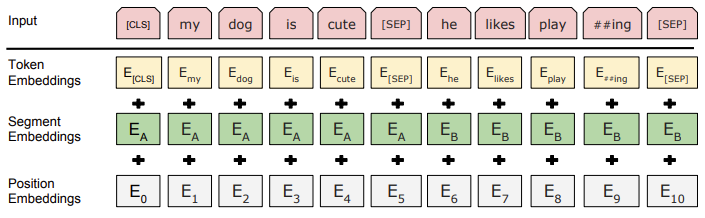

우선 몇 가지 유틸리티 함수를 정의하겠습니다.

In [ ]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


여기서는 ReLU가 아닌 GELU를 사용하겠습니다. 일반적으로 GELU는 ReLU나 ELU보다 성능이 좋다고 합니다. 아래의 그래프는 [GELU 논문](https://arxiv.org/pdf/1606.08415)에 나온 GELU, ReLU, ELU 함수를 비교하여 나타낸 것입니다.

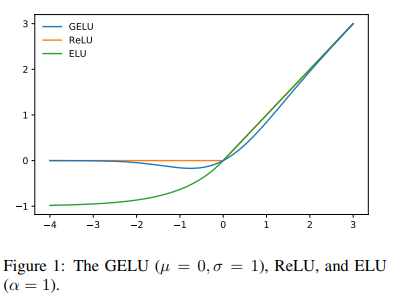


[GELU, ReLU, ELU 함수]

 https://arxiv.org/pdf/1606.08415.pdf

GELU 함수의 식은 GELU 함수 아래와 같습니다.

$$0.5 \times \left( 1 + \tanh \left[ \sqrt{2/\pi} (x + 0.044715x^3) \right] \right)$$

In [ ]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [ ]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [ ]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


이제 본격적으로 embedding 레이어를 쌓아나가겠습니다. 아래는 Token Embedding의 구현입니다.

In [ ]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


Position Embedding 레이어는 다음과 같습니다.

Transformer이 사인 함수와 코사인 함수를 이용한 Positional Encoding을 통해 토큰의 상대적인 위치를 학습했던 것과 달리, BERT에서는 Position Embedding을 사용합니다. Position Embedding은 위치 정보가 담긴 임베딩 레이어를 하나 더 사용해 Position Embedding 벡터를 학습시켜서, BERT의 입력에 Position Embedding을 더해줍니다.

In [ ]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


상대적으로 매우 간단한 Segment Embedding은 별도의 레이어를 구현하지 않고 BERT 클래스에서 간단히 포함하도록 하겠습니다. Segment Embedding는 두 개의 문장을 구분하기 위한 임베딩이었던 것은 기억나시죠?

아래는 Transformer에서 자주 보았던 `ScaleDotProductAttention`과 이를 활용한 `MultiHeadAttention`입니다.

In [ ]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


In [ ]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


<details>
<summary>예시코드</summary>
<div markdown="1">



```
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        # attn_mask 변환
        attn_mask_m = attn_mask.unsqueeze(1)
        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)
        
        return attn_out
print("슝=3")
```



</div>
</details>

이를 바탕으로 transformer encoder 레이어를 구성하겠습니다.

In [ ]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [ ]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


이제 다 왔습니다.

최종적으로 구성할 BERT 레이어는 아래와 같습니다.

In [ ]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


BERT 레이어를 바탕으로 최종적으로 만들어질 pretrain용 BERT 모델 구성은 아래와 같습니다.

In [ ]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits 반환 (softmax 제거: CrossEntropyLoss가 처리)

print("슝=3")

슝=3


In [ ]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = logits_cls  # raw logits (이중 softmax 제거)

        outputs_mlm = logits_lm  # raw logits (softmax 제거)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


아주 작은 pretrain용 BERT 모델(test_model)을 생성하여 동작을 확인해 보겠습니다.

In [ ]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

In [ ]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.289597034454346
Epoch 2/2 - Loss: 9.138312816619873


학습 과정에서 `model.train()`과 `optimizer.step()`을 활용해 손실을 줄이며 모델을 최적화했습니다.

다음 스텝에서 본격적으로 학습을 진행해 보겠습니다.

# pretrain 진행

loss와 accuracy같이 기본적으로 필요한 계산 함수를 미리 정의해 둡시다. 학습 데이터의 label이 정수로 변환되었으므로 loss 함수는 `SparseCategoricalCrossentropy`와 동일한 역할을 수행하는 `F.cross_entropy`를 사용합니다. MLM task에 대해 더 잘 학습하도록 loss를 20배 증가시켜 줍니다.

In [ ]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [ ]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


Learning Rate 스케줄링도 아래와 같이 구현합니다. WarmUp 이후 consine 형태로 감소하는 스케줄을 적용합니다.

최근에는 Learning Rate를 단순히 감소시키기 보다는 진동하면서 최적점을 찾아가는 방식을 많이 사용하고 있습니다. 다양한 방법을 찾아서 적용시켜 보는 것도 성능을 높이는 좋은 방법입니다.

In [ ]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

슝=3


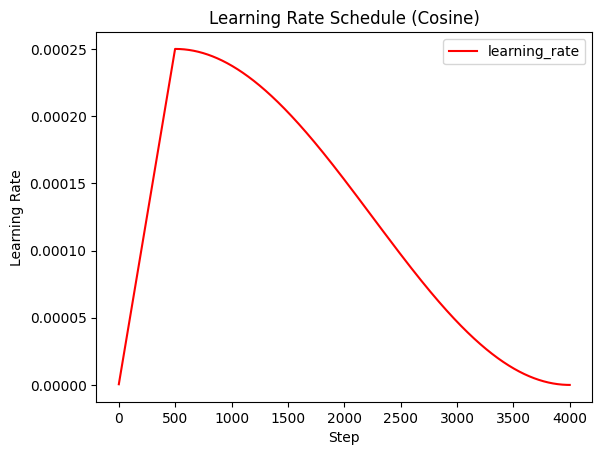

In [ ]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

이제 모델을 실제로 빌드해 봅시다.

In [ ]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [ ]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            640,000
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]         

이제 본격적으로 학습을 진행합니다. 1 Epoch만 학습하는 데도 10분 이상의 상당한 시간이 소요될 것입니다. 메모리 오류가 날 수 있으니 배치 사이즈에도 유의해 주세요. 우리는 전체 데이터셋 중의 1/7 수준인 128,000건만 로딩해서 사용 중이라는 것을 기억합시다.

optimizer는 Adam을 사용하고, MLM과 NSP에 대한 loss와 accuracy를 알 수 있도록 하였습니다.

In [ ]:
epochs = 2
batch_size = 64

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)  # 0=[PAD]/비마스크 위치 제외

train_steps: 4000


학습시킨 모델을 콜백 함수를 사용해 저장하고, 시각화해 봅시다.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        lr = learning_rate_scheduler.step()  # LR 스케줄러 실제 적용
        for g in optimizer.param_groups:
            g['lr'] = lr

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)  # 마스킹된 위치만 평가
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{model_dir}/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/2 - Loss: 5.486860250711441, NSP Loss: 0.6116145819425582, MLM Loss: 4.875245667219162, NSP Accuracy: 0.5973828125, MLM Accuracy: 0.4971131604472757
Epoch 2/2 - Loss: 5.152274393320083, NSP Loss: 0.5890576389878989, MLM Loss: 4.563216753959656, NSP Accuracy: 0.6013125, MLM Accuracy: 0.504127550303936


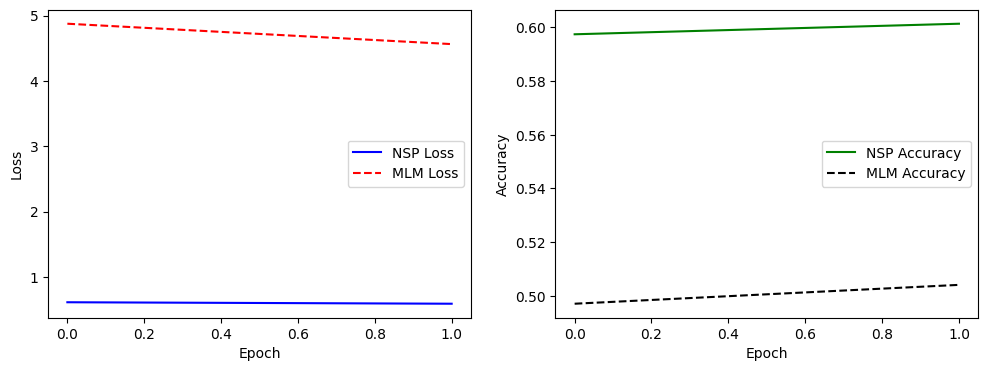

In [ ]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 프로젝트 : mini BERT 만들기

지금까지 BERT 모델을 pretrain하는 험난한 여정을 잘 따라오셨나요?

이번 프로젝트의 과제는 간단합니다.

vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 1M 정도가 되는 아주 작은 mini BERT 모델을 만들어 10 Epoch까지 학습시킨 모델을 만들어 보는 것입니다.

## 라이브러리 버전을 확인해 봅니다.
---
사용할 라이브러리 버전을 둘러봅시다.

In [ ]:
import torch
import numpy
import pandas
import matplotlib
import json
import re

print(torch.__version__)
print(numpy.__version__)
print(pandas.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

2.11.0+cu128
2.0.2
2.2.2
3.10.0
2.0.9
2.2.1


## 1. Tokenizer 준비
---
SentencePiece 모델을 이용해 BERT의 MLM 학습용 데이터를 만드세요.

이를 위해 한글 나무 위키 코퍼스로부터 8000의 vocab_size를 갖는 sentencepiece 모델을 만들어 보세요. BERT에 사용되는 주요 특수문자가 vocab에 포함되어야 합니다. (시간이 부족하다면 클라우드에 저장된 sentencepiece 모델을 사용하세요.)

## 2. 데이터 전처리 (1) MASK 생성
---
BERT의 MLM에 필요한 빈칸(mask)을 학습 데이터 전체 토큰의 15% 정도로 만들어 주세요. 그 중 80%는 `[MASK]` 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용하세요.

## 3. 데이터 전처리 (2) NSP pair 생성
---
BERT의 pretrain task인 NSP는 두 문장이 연속하는지 확인하는 것입니다. 이를 위해 2개의 문장을 짝지어 50%의 확률로 `TRUE`와 `FALSE`를 지정해 주세요.

두 문장 사이에 segment 처리를 해주세요. 첫 번째 문장의 segment는 0, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 [SEP] 등을 넣어주세요.

MLM과 NSP는 동시에 학습된다는 것을 염두에 두고 학습 데이터를 구성해 보세요.

## 4. 데이터 전처리 (3) 데이터셋 완성
---
BERT pretrain 데이터셋을 생성해, json 포맷으로 저장하세요. 데이터셋의 사이즈가 크므로`np.memmap`을 사용해 메모리 사용량을 최소화해 보세요.

## 5. BERT 모델 구현
---
pad mask, ahead mask 함수, gelu activation 함수, parameter initializer 생성 함수, json을 config 형태로 사용하기 위한 유틸리티 함수를 먼저 만들어 두세요.

Embedding 레이어, Transformer encoder 레이어, BERT 레이어를 구성한 후, pretraine용 BERT 모델을 만들어 봅시다.

## 6. pretrain 진행
---
loss, accuracy 함수를 정의하고 Learning Rate 스케쥴링을 구현한 후, 10 Epoch까지 모델 학습을 시켜보세요. 학습을 진행할 때는 배치 사이즈에 유의하세요.

## 7. 프로젝트 결과
---
학습된 모델과 학습과정을 시각화해 보세요. NSP와 MLM의 loss가 안정적으로 수렴하나요? 모델이 작기 때문에 loss가 잘 수렴하지 않을 수도 있어요.

---
---

# 🎯 프로젝트 : mini BERT 만들기

## 이 노트북에서 하는 일

한국어 위키 코퍼스로 **파라미터 약 1M짜리 아주 작은 BERT**를 밑바닥부터 만들어 pretrain 시킵니다.
원본 BERT-large(340M)의 **약 1/300** 크기지만, **거치는 과정은 원본과 완전히 동일**합니다.

## 제출 루브릭과 이 노트북의 대응

| # | 학습목표 | 평가기준 | 해당 섹션 |
|---|---|---|---|
| 1 | 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 잘 생성하였다 | MLM, NSP task의 특징이 잘 반영된 pretrain용 데이터셋 생성과정이 체계적으로 진행되었다 | **STEP 1 ~ 4** |
| 2 | 구현한 BERT 모델의 학습이 안정적으로 진행됨을 확인하였다 | 학습진행 과정 중에 MLM, NSP loss의 안정적인 감소가 확인되었다 | **STEP 6, 7** |
| 3 | 1M짜리 mini BERT 모델의 제작과 학습이 정상적으로 진행되었다 | 학습된 모델 및 학습과정의 시각화 내역이 제출되었다 | **STEP 5, 7, 8** |

각 섹션 끝에는 `✅ 루브릭 N 근거` 라고 표시된 **검증 셀**을 두었습니다.
말로만 "했습니다"가 아니라, 코드를 돌려 나온 출력으로 확인할 수 있게 했습니다.

## 실행 순서

이 섹션은 **위 튜토리얼과 독립적으로** 돌아가도록 작성했습니다.
(튜토리얼은 vocab 32,000을 쓰지만 이 프로젝트는 vocab 8,000을 쓰기 때문에, 토크나이저·데이터셋을 새로 만듭니다.)

```
STEP 0  환경 설정            →  1분
STEP 1  토크나이저 (vocab 8000)  →  10~20분
STEP 2  MLM 마스킹 구현        →  즉시
STEP 3  NSP 페어 생성          →  즉시
STEP 4  데이터셋 생성           →  10~15분
STEP 5  mini BERT 모델 (1M)    →  즉시
STEP 6  10 Epoch 학습          →  20~40분 (GPU)
STEP 7  결과 시각화 / 모델 저장   →  1분
STEP 8  회고
```

> ⚠️ **런타임 유형을 GPU로 바꿔주세요.** (런타임 → 런타임 유형 변경 → T4 GPU)
> CPU로 돌리면 STEP 6에서 몇 시간이 걸립니다.


## STEP 0 · 환경 설정

재현 가능한 결과를 위해 seed를 고정하고, 프로젝트 전용 경로를 따로 잡습니다.
튜토리얼에서 만든 파일(`ko_32000.*`, `bert_pre_train.json`)과 **섞이지 않도록** 이름을 다르게 둡니다.


In [ ]:
# ============================================================
# STEP 0 · 환경 설정
# ============================================================
from __future__ import absolute_import, division, print_function, unicode_literals

import os, re, math, json, copy, random, collections, shutil, zipfile
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import sentencepiece as spm
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ---- 재현성 : seed 고정 ----
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---- 경로 (튜토리얼 파일과 분리) ----
DATA_DIR  = '/content/data'
MODEL_DIR = '/content/models'
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

CORPUS_FILE  = f'{DATA_DIR}/kowiki.txt'          # 원본 코퍼스
SPM_PREFIX   = f'{MODEL_DIR}/ko_8000'            # 프로젝트용 토크나이저
PRETRAIN_JSON= f'{DATA_DIR}/mini_bert_pretrain.json'   # 프로젝트용 데이터셋
CKPT_PATH    = f'{MODEL_DIR}/mini_bert_1M.pth'   # 학습된 모델
HIST_PATH    = f'{MODEL_DIR}/mini_bert_history.json'   # 학습 기록

# ---- matplotlib 한글 폰트 (STEP 7 그래프가 깨지지 않도록) ----
import matplotlib.font_manager as fm
_font = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
try:
    if not os.path.exists(_font):
        print("한글 폰트 설치 중...")
        os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')
        os.system('fc-cache -fv > /dev/null 2>&1')
    fm.fontManager.addfont(_font)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    print("한글 폰트   : NanumGothic 설정 완료")
except Exception as e:
    print("한글 폰트   : 설정 실패 → 그래프 한글이 깨질 수 있습니다 (", e, ")")

# ---- 디바이스 ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch       :", torch.__version__)
print("device      :", device)
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
else:
    print("⚠️  GPU가 아닙니다. 런타임 → 런타임 유형 변경 → T4 GPU 로 바꿔주세요.")
print("코퍼스 존재  :", os.path.exists(CORPUS_FILE), CORPUS_FILE)

---

## STEP 1 · 토크나이저 준비 (vocab 8,000)

### 왜 subword(BPE)인가

단어 단위로 사전을 만들면 **사전에 없는 단어(OOV)** 를 만났을 때 전부 `[UNK]`가 되어 정보가 사라집니다.
BPE는 자주 붙어 나오는 **글자 쌍을 합쳐 조각(subword)** 을 만들기 때문에,
처음 보는 단어도 조각의 조합으로 표현할 수 있습니다.

### 이 프로젝트의 선택 : vocab_size = 8,000

튜토리얼은 32,000을 썼지만, 프로젝트 목표가 **1M 파라미터**이므로 8,000으로 줄입니다.

> **왜 vocab을 줄이면 파라미터가 확 주는가?**
> 임베딩 행렬 크기가 `vocab_size × d_model`이기 때문입니다.
> STEP 5에서 실제로 계산해 보면, 전체 파라미터의 **73%가 이 임베딩 행렬 하나**입니다.
> vocab을 32,000 → 8,000으로 줄이면 이 행렬이 1/4로 줄어듭니다.

### ⚠️ 반드시 지켜야 할 것 : `vocab_size + 7`

BERT에 필요한 특수토큰 **7개**의 자리를 따로 확보해야 합니다.

| 토큰 | id | 역할 |
|---|---|---|
| `[PAD]` | 0 | 길이 맞추기용 채우기 (loss에서 제외) |
| `[UNK]` | 1 | 사전에 없는 토큰 |
| `[BOS]` | 2 | 문장 시작 |
| `[EOS]` | 3 | 문장 끝 |
| `[SEP]` | 4 | 문장 구분자 |
| `[CLS]` | 5 | 문장 대표 자리 (분류·NSP의 답이 여기서 나옴) |
| `[MASK]` | 6 | 가려진 빈칸 (MLM의 정답 대상) |

이걸 빠뜨리면 나중에 `[MASK]`가 사전에 없어서 학습이 통째로 터집니다.


In [ ]:
# ============================================================
# STEP 1-1 · SentencePiece(BPE) 학습 — vocab 8,000
# ============================================================
# 소요: 10~20분. 이미 만들어져 있으면 건너뜁니다.

VOCAB_SIZE = 8000

if os.path.exists(f'{SPM_PREFIX}.model'):
    print(f"이미 존재 → 학습 건너뜀 : {SPM_PREFIX}.model")
else:
    print("SentencePiece 학습 시작 (10~20분 소요)...")
    spm.SentencePieceTrainer.train(
        f"--input={CORPUS_FILE}"
        f" --model_prefix={SPM_PREFIX}"
        f" --vocab_size={VOCAB_SIZE + 7}"          # ★ 특수토큰 7개 자리 확보
        f" --model_type=bpe"
        f" --max_sentence_length=999999"
        f" --pad_id=0 --pad_piece=[PAD]"
        f" --unk_id=1 --unk_piece=[UNK]"
        f" --bos_id=2 --bos_piece=[BOS]"
        f" --eos_id=3 --eos_piece=[EOS]"
        f" --user_defined_symbols=[SEP],[CLS],[MASK]"
    )
    print("완료 :", f'{SPM_PREFIX}.model')

In [ ]:
# ============================================================
# STEP 1-2 · 토크나이저 로드 & vocab_list 생성
# ============================================================
vocab = spm.SentencePieceProcessor()
vocab.load(f"{SPM_PREFIX}.model")

# 특수토큰 7개를 제외한 일반 토큰 목록
# (MLM에서 "10% 랜덤 토큰으로 치환"할 때 뽑아 쓸 후보군)
vocab_list = []
for i in range(7, len(vocab)):
    if not vocab.is_unknown(i):
        vocab_list.append(vocab.id_to_piece(i))

N_VOCAB = len(vocab)          # ★ 8007 — 모델 config에서 반드시 이 값을 써야 함
print("전체 vocab 크기 :", N_VOCAB)
print("일반 토큰 개수   :", len(vocab_list))
print("샘플 토큰        :", vocab_list[:15])

In [ ]:
# ============================================================
# ✅ 루브릭 1 근거 ① — 특수토큰이 vocab에 제대로 들어갔는가
# ============================================================
print("[특수토큰 id 확인]")
expect = {"[PAD]": 0, "[UNK]": 1, "[BOS]": 2, "[EOS]": 3, "[SEP]": 4, "[CLS]": 5, "[MASK]": 6}
ok = True
for piece, want in expect.items():
    got = vocab.piece_to_id(piece)
    mark = "OK " if got == want else "!! "
    if got != want:
        ok = False
    print(f"  {mark}{piece:<8} id = {got:<3} (기대 {want})")
assert ok, "특수토큰 id가 기대와 다릅니다. vocab_size+7 옵션을 확인하세요."

print("\n[토크나이징 동작 확인]")
sample = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
pieces = vocab.encode_as_pieces(sample)
print("  원문   :", sample)
print("  토큰   :", pieces)
print("  id     :", vocab.encode_as_ids(sample))
print("  복원   :", vocab.decode_pieces(pieces))

print("\n[▁ 기호 확인 — STEP 2에서 핵심적으로 쓰임]")
print("  ▁로 시작 = 새 단어의 시작, 아니면 = 앞 단어에서 이어진 조각")
for p in pieces[:6]:
    kind = "새 단어 시작" if p.startswith("▁") else "  이어진 조각"
    print(f"    {p:<8} → {kind}")

print("\n✅ 특수토큰 7개 정상 확보, 토크나이저 정상 동작")

---

## STEP 2 · 데이터 전처리 (1) MLM 마스킹

### MLM(Masked Language Model)이란

문장의 일부를 가리고 **빈칸에 뭐가 들어갈지 맞히는 문제**입니다.

```
원문 :  오늘  날씨가  정말  좋아서  공원에  갔다
입력 :  오늘  날씨가  정말  [MASK]  공원에  갔다
정답 :                      좋아서
```

**왜 이 문제여야 했나?**
GPT처럼 "다음 단어 맞히기"를 하면 뒤를 볼 수 없습니다(답이 보이니까 = 컨닝).
그런데 **빈칸 맞히기는 앞뒤를 다 봐도 컨닝이 아닙니다.**
그래서 BERT는 모든 층에서 **양방향(Bidirectional)** 이 가능해집니다. ← BERT의 B

### 규칙 ① 전체 토큰의 15%를 고른다

### 규칙 ② 고른 15% 안에서 다시 80 : 10 : 10

| 비율 | 처리 | 전체 대비 | 이유 |
|---|---|---|---|
| 80% | `[MASK]`로 치환 | 12% | 정석. 빈칸을 만들고 맞히게 함 |
| 10% | 랜덤한 다른 토큰으로 치환 | 1.5% | 엉뚱한 단어가 와도 문맥으로 알아채도록 |
| 10% | 원래 토큰 그대로 둠 | 1.5% | 멀쩡한 자리도 예측시켜 문장 전체를 이해하도록 |

**왜 100%를 `[MASK]`로 하지 않는가?**
fine-tuning 할 때 실제 입력에는 `[MASK]`가 **하나도 없기 때문**입니다.
100% `[MASK]`로 학습하면 모델이 "`[MASK]`라고 써 있는 자리만 맞히면 된다"고 배웁니다.
그러면 학습 때 본 것과 실전이 어긋나서 성능이 떨어집니다.

### 규칙 ③ (중요) 띄어쓰기 단위로 통째 가린다 — 논문에 없는 구현 디테일

논문에는 "15%를 랜덤하게 가린다"고만 나옵니다. 그런데 그대로 짜면 문제가 생깁니다.

```
❌ 조각 하나만 가리면
   ▁대  [MASK]  민국      → 빈칸이 '한'인 걸 너무 쉽게 맞힘
                            ('대한민국' 패턴을 수천 번 봤으니까)
                            → 모델이 문맥이 아니라 철자를 외움

✅ 띄어쓰기 단위로 통째 가리면
   [MASK] [MASK] [MASK]   → 진짜로 앞뒤 문맥을 봐야만 풀림
```

이걸 구현하는 열쇠가 STEP 1에서 본 **`▁`(U+2581) 기호**입니다.
토큰이 `▁`로 시작하면 새 단어, 아니면 앞 단어의 이어진 조각 → **같은 묶음으로 만들어 함께 마스킹**합니다.

> 이 방식이 BERT 후속 논문의 **Whole Word Masking**이고, **ERNIE**가 이를 구(phrase)·고유명사(entity) 단위로 확장한 것입니다.


In [ ]:
# ============================================================
# STEP 2 · MLM 마스킹 생성 함수
# ============================================================
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    MLM용 마스크 생성
    :param tokens:     토큰 리스트 ([CLS] ... [SEP] ... [SEP])
    :param mask_cnt:   마스킹할 개수 (전체의 15%)
    :param vocab_list: 랜덤 치환용 후보 토큰 목록
    :return tokens:     마스킹이 적용된 토큰
    :return mask_idx:   마스킹된 위치
    :return mask_label: 그 위치의 원래 값 (정답)
    """
    # ---- ① 띄어쓰기(단어) 단위로 index 를 묶는다 ----
    #      '▁' 로 시작 = 새 단어 / 아니면 = 앞 단어에서 이어진 조각
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue                                     # 특수토큰은 마스킹 대상 제외
        if 0 < len(cand_idx) and not token.startswith(u"▁"):
            cand_idx[-1].append(i)                       # 앞 묶음에 붙인다
        else:
            cand_idx.append([i])                         # 새 단어 시작

    # ---- ② 랜덤 마스킹을 위해 단어 묶음 순서를 섞는다 ----
    random.shuffle(cand_idx)

    # ---- ③ 15% 를 채울 때까지 묶음 단위로 마스킹 ----
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break                                        # 15% 도달 → 중지
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue                                     # 이 묶음을 넣으면 초과 → 건너뜀

        dice = random.random()                           # ★ 묶음당 한 번만 굴린다
                                                         #   (한 단어는 통째로 같은 처리)
        for index in index_set:
            if dice < 0.8:
                masked_token = "[MASK]"                  # 80%
            elif dice < 0.9:
                masked_token = tokens[index]             # 10% — 원래 토큰 유지
            else:
                masked_token = random.choice(vocab_list) # 10% — 랜덤 토큰
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # ---- ④ 위치 순으로 정렬 후 분리 ----
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx   = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

print("create_pretrain_mask 정의 완료")

In [ ]:
# ============================================================
# ✅ 루브릭 1 근거 ② — 마스킹이 의도대로 동작하는가
# ============================================================
random.seed(SEED)

demo = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(demo) + ["[SEP]"]
mask_cnt   = int((len(tokens_org) - 2) * 0.15)

print("[1] 띄어쓰기 단위로 묶이는지 확인")
cand_idx = []
for (i, t) in enumerate(tokens_org):
    if t in ("[CLS]", "[SEP]"):
        continue
    if 0 < len(cand_idx) and not t.startswith(u"▁"):
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])
for c in cand_idx[:8]:
    print(f"    {str(c):<12} {[tokens_org[i] for i in c]}")
print(f"    ... 총 {len(cand_idx)}개 단어 묶음  (토큰 {len(tokens_org)}개)")

print("\n[2] 마스킹 결과")
tokens = copy.deepcopy(tokens_org)
tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)
print("    원문 :", " ".join(tokens_org[:22]))
print("    입력 :", " ".join(tokens[:22]))
print(f"\n    마스킹 대상 : {mask_cnt}개 / 전체 {len(tokens_org)}개 = {mask_cnt/len(tokens_org)*100:.1f}%")
print("    mask_idx    :", mask_idx)
print("    mask_label  :", mask_label)

print("\n[3] 마스킹된 자리가 단어 단위로 '연속'되는지 확인")
groups, cur = [], [mask_idx[0]]
for a, b in zip(mask_idx, mask_idx[1:]):
    if b == a + 1:
        cur.append(b)
    else:
        groups.append(cur); cur = [b]
groups.append(cur)
for g in groups:
    print(f"    {str(g):<14} 원래값 {[tokens_org[i] for i in g]}")
print("\n✅ 조각 하나가 아니라 단어 묶음 단위로 마스킹됨을 확인")

In [ ]:
# ============================================================
# ✅ 루브릭 1 근거 ③ — 80 : 10 : 10 비율이 실제로 지켜지는가
# ============================================================
# 마스킹을 여러 번 반복해서, 실제로 나온 비율을 실측합니다.
random.seed(SEED)

n_mask, n_keep, n_rand = 0, 0, 0
N_TRIAL = 2000

for _ in range(N_TRIAL):
    t = copy.deepcopy(tokens_org)
    t, m_idx, m_lab = create_pretrain_mask(t, mask_cnt, vocab_list)
    for i, lab in zip(m_idx, m_lab):
        if t[i] == "[MASK]":
            n_mask += 1
        elif t[i] == lab:
            n_keep += 1        # 원래 토큰 그대로
        else:
            n_rand += 1        # 랜덤 토큰으로 치환

tot = n_mask + n_keep + n_rand
print(f"{'처리':<22}{'실측':>10}{'목표':>8}")
print("-" * 42)
print(f"{'[MASK] 로 치환':<20}{n_mask/tot*100:>9.1f}%{80:>7}%")
print(f"{'원래 토큰 그대로':<20}{n_keep/tot*100:>9.1f}%{10:>7}%")
print(f"{'랜덤 토큰으로 치환':<19}{n_rand/tot*100:>9.1f}%{10:>7}%")
print("-" * 42)
print(f"{'합계':<21}{tot:>9,}개 (시행 {N_TRIAL}회)")
print(f"\n전체 토큰 대비 → [MASK] {n_mask/tot*15:.1f}% / 유지 {n_keep/tot*15:.1f}% / 랜덤 {n_rand/tot*15:.1f}%")
print("   (BERT 논문 기준 : 12% / 1.5% / 1.5%)")
print("\n✅ 80:10:10 비율이 의도대로 구현됨")
print("   ※ '원래 토큰 그대로'는 겉보기엔 안 가려진 것 같지만,")
print("      mask_label 에 정답이 들어가 있으므로 loss 계산 대상이 됩니다.")

---

## STEP 3 · 데이터 전처리 (2) NSP 페어 생성

### NSP(Next Sentence Prediction)란

문장 두 개를 붙여놓고 **"이거 진짜 이어지는 문장이야?"** 를 맞히는 O/X 문제입니다.

```
[CLS] 여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 그 사람이 바다의 뚜껑 닫지 않고 돌아가 [SEP]
   → TRUE  (IsNext)     is_next = 1

[CLS] 여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 한강에서 자전거 타며 아이스 아메리카노를 마시고 싶다 [SEP]
   → FALSE (NotNext)    is_next = 0
```

이걸 학습하면 모델이 **문장과 문장 사이의 관계**를 익히게 됩니다.
답은 맨 앞의 `[CLS]` 토큰 벡터로 2지선다 분류를 해서 냅니다.

### 만드는 절차

| # | 단계 | 내용 |
|---|---|---|
| 1 | 문단을 모은다 | 위키는 **빈 줄**로 문단이 나뉨 → 빈 줄 나올 때까지 모아 한 문단(doc) |
| 2 | 임의 지점에서 자른다 | `a_end = random.randrange(...)` → 앞은 `tokens_a`, 뒤는 `tokens_b` |
| 3 | **50% 확률로 뒤집는다** | 뒤집으면 `is_next=0`(FALSE), 그대로면 `is_next=1`(TRUE) |
| 4 | 길이를 맞춘다 | `trim_tokens()` — `max_seq` 넘으면 잘라냄 |
| 5 | 특수토큰 + segment | `[CLS] A [SEP] B [SEP]` / segment `0...0 1...1` |
| 6 | MLM 마스킹 | STEP 2의 `create_pretrain_mask()` 를 여기서 호출 |

> **재밌는 점** — FALSE 데이터를 만들려고 굳이 다른 문서에서 문장을 가져올 필요가 없습니다.
> **그냥 앞뒤 순서만 바꾸면** 됩니다.

### 구현하며 걸렸던 부분 2가지

**① `trim_tokens`는 긴 쪽에서 지우되, A는 앞에서 / B는 뒤에서 지운다**
```python
if len(tokens_a) > len(tokens_b): del tokens_a[0]   # A는 앞에서
else:                             tokens_b.pop()    # B는 뒤에서
```
왜? **두 문장이 만나는 경계 부분을 살리기 위해서**입니다.
경계가 NSP 판단의 핵심 단서인데, 거기부터 잘라버리면 문제가 안 풀립니다.

**② segment 길이는 `+2`, `+1`**
```python
segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
#                              ↑ [CLS], [SEP]          ↑ [SEP]
```
특수토큰 자리까지 세야 해서, 여기서 길이가 자꾸 어긋나 `assert`에 걸렸습니다.

### MLM과 NSP는 **한 데이터에 같이** 들어간다

BERT의 pretrain은 두 task를 **동시에** 학습합니다.
따라서 데이터 1건에 `tokens`(마스킹됨), `segment`, `is_next`, `mask_idx`, `mask_label`이 **모두** 들어갑니다.


In [ ]:
# ============================================================
# STEP 3-1 · 길이 조절 함수
# ============================================================
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a + tokens_b 의 총 길이를 max_seq 이하로 줄인다.
    ★ 긴 쪽에서 지우되, A는 앞에서(del[0]) / B는 뒤에서(pop())
      → 두 문장이 만나는 '경계'를 최대한 보존하기 위함
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]      # A는 앞에서 지운다
        else:
            tokens_b.pop()       # B는 뒤에서 지운다


# ============================================================
# STEP 3-2 · 문단(doc) 하나에서 학습 데이터 만들기
# ============================================================
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    문단 하나로부터 (NSP + MLM)이 결합된 학습 데이터를 만든다.
    :param doc:   [[토큰...], [토큰...], ...]  줄 단위로 토크나이징된 문단
    :param n_seq: 최대 시퀀스 길이
    """
    max_seq = n_seq - 3          # [CLS], [SEP], [SEP] 자리 3개 제외

    instances = []
    current_chunk  = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        # 마지막 줄이거나, 길이가 max_seq 를 넘으면 → 데이터 1건 생성
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):

            # ---- ① 임의 지점에서 A / B 로 자른다 ----
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # ---- ② 50% 확률로 순서를 뒤집는다 (NSP 라벨 생성) ----
            if random.random() < 0.5:
                is_next = 0                              # FALSE (NotNext)
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1                              # TRUE  (IsNext)

            # ---- ③ 길이 조절 ----
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # ---- ④ 특수토큰 + segment ----
            tokens  = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            assert len(tokens) == len(segment)

            # ---- ⑤ MLM 마스킹 (STEP 2) ----
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            # ---- ⑥ MLM + NSP 가 한 건에 함께 들어간다 ----
            instances.append({
                "tokens":     tokens,       # 마스킹된 입력
                "segment":    segment,      # 0=문장A, 1=문장B
                "is_next":    is_next,      # NSP 정답
                "mask_idx":   mask_idx,     # MLM 정답 위치
                "mask_label": mask_label,   # MLM 정답 값
            })

            current_chunk  = []
            current_length = 0

    return instances

print("trim_tokens / create_pretrain_instances 정의 완료")

In [ ]:
# ============================================================
# ✅ 루브릭 1 근거 ④ — NSP 데이터가 의도대로 만들어지는가
# ============================================================
random.seed(SEED)

poem = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어"""

doc = [vocab.encode_as_pieces(line) for line in poem.split("\n")]
insts = create_pretrain_instances(vocab, doc, 64, 0.15, vocab_list)

print(f"문단 {len(doc)}줄 → 학습 데이터 {len(insts)}건 생성\n")
for k, inst in enumerate(insts):
    print(f"--- 데이터 {k+1} ---")
    print("  is_next :", inst["is_next"], "(1=TRUE 이어짐 / 0=FALSE 안 이어짐)")
    print("  tokens  :", " ".join(inst["tokens"]))
    print("  segment :", "".join(str(x) for x in inst["segment"]))
    print("  → 문장A 길이", inst["segment"].count(0), "/ 문장B 길이", inst["segment"].count(1))
    print("  mask_idx / label :", inst["mask_idx"], inst["mask_label"])
    assert len(inst["tokens"]) == len(inst["segment"]), "tokens와 segment 길이 불일치!"
    print()

print("✅ [CLS] A [SEP] B [SEP] 구조 / segment 0·1 분리 / MLM+NSP 동시 포함 확인")

In [ ]:
# ============================================================
# ✅ 루브릭 1 근거 ⑤ — NSP TRUE/FALSE 가 50:50 인가
# ============================================================
random.seed(SEED)

cnt = collections.Counter()
for _ in range(3000):
    insts = create_pretrain_instances(vocab, doc, 64, 0.15, vocab_list)
    for inst in insts:
        cnt[inst["is_next"]] += 1

tot = sum(cnt.values())
print(f"{'라벨':<26}{'개수':>8}{'비율':>9}{'목표':>8}")
print("-" * 52)
print(f"{'1  TRUE  (IsNext)':<25}{cnt[1]:>8,}{cnt[1]/tot*100:>8.1f}%{50:>7}%")
print(f"{'0  FALSE (NotNext)':<25}{cnt[0]:>8,}{cnt[0]/tot*100:>8.1f}%{50:>7}%")
print("-" * 52)
print(f"{'합계':<25}{tot:>8,}")
print("\n✅ NSP 라벨이 50:50 으로 균형있게 생성됨")
print("   → 한쪽으로 치우치면 모델이 '무조건 TRUE'만 찍어도 점수가 나오므로 중요합니다.")

---

## STEP 4 · 데이터 전처리 (3) 데이터셋 완성

### 이번 프로젝트에서 제일 현실적인 벽

| 항목 | 크기 |
|---|---|
| 한국어 위키 원본 | 232 MB / 약 400만 줄 |
| 생성되는 JSON 데이터셋 | **약 1.4 GB** |
| 실제 학습에 로딩할 건수 | 128,000 건 (일부) |

마스킹 정보·segment·라벨이 다 붙기 때문에 **데이터셋이 원본보다 커집니다.**

### 문제 : 램이 감당 못 한다

```python
enc_tokens = np.zeros((total, n_seq), np.int32)   # ← 이러면 터짐
```
`(total, 128)` 짜리 배열을 **4개**(tokens, segments, nsp라벨, mlm라벨) 올려야 합니다.
이게 실제 BERT 학습 데이터의 **1/100** 크기인데도 그렇습니다.

### 해결 : `np.memmap`

```python
enc_tokens = np.memmap(filename='...', mode='w+', dtype=np.int32, shape=(total, n_seq))
```
배열을 **램이 아니라 디스크 파일**에 두고, 필요한 부분만 그때그때 읽어옵니다.
코드는 일반 numpy 배열과 **똑같이** 쓰면서 메모리는 거의 쓰지 않습니다.
(속도를 조금 내주고 메모리를 얻는 트레이드오프)

### MLM 라벨을 만드는 방식 (중요)

```python
label_mlm = np.full(n_seq, fill_value=0)      # 전부 0으로 채우고
label_mlm[mask_idx] = mask_label              # 마스킹된 자리에만 정답을 꽂는다
```
즉 **`0`은 "여긴 마스킹 안 된 자리니까 무시해"** 라는 뜻입니다.
`[PAD]`의 id도 0이므로, STEP 6에서 `ignore_index=0`으로 두면
**패딩과 비마스킹 자리가 한꺼번에 loss에서 제외**됩니다.


In [ ]:
# ============================================================
# STEP 4-1 · 코퍼스 전체 → JSON 데이터셋
# ============================================================
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """코퍼스를 읽어 pretrain 데이터셋(json lines)을 만든다."""
    # 특수토큰 7개를 제외한 vocab_list (랜덤 치환용)
    v_list = []
    for i in range(7, len(vocab)):
        if not vocab.is_unknown(i):
            v_list.append(vocab.id_to_piece(i))

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, v_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 전체 라인 수 (진행바용)
    line_cnt = 0
    with open(in_file, "r") as f:
        for _ in f:
            line_cnt += 1

    with open(in_file, "r") as in_f, open(out_file, "w") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt, desc="데이터셋 생성"):
            line = line.strip()
            if line == "":                       # 빈 줄 = 문단의 끝
                if 0 < len(doc):
                    save_pretrain_instances(out_f, doc)
                    doc = []
            else:
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)
        if 0 < len(doc):                         # 마지막 문단 처리
            save_pretrain_instances(out_f, doc)


N_SEQ = 128        # 최대 시퀀스 길이

random.seed(SEED)
if os.path.exists(PRETRAIN_JSON):
    print(f"이미 존재 → 생성 건너뜀 : {PRETRAIN_JSON}")
else:
    print("데이터셋 생성 시작 (10~15분 소요)...")
    make_pretrain_data(vocab, CORPUS_FILE, PRETRAIN_JSON, N_SEQ, mask_prob=0.15)

size_gb = os.path.getsize(PRETRAIN_JSON) / 1024**3
print(f"\n데이터셋 파일 : {PRETRAIN_JSON}")
print(f"파일 크기     : {size_gb:.2f} GB")

In [ ]:
# ============================================================
# STEP 4-2 · np.memmap 으로 메모리 효율적 로딩
# ============================================================
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    JSON 데이터셋을 np.memmap 으로 로딩한다.
    :return (enc_tokens, segments), (labels_nsp, labels_mlm)
    """
    # ---- 로딩할 건수 파악 ----
    total = 0
    with open(filename, "r") as f:
        for _ in f:
            total += 1
            if count is not None and count <= total:
                break

    # ---- 램이 아니라 디스크에 배열을 잡는다 ----
    enc_tokens = np.memmap(filename=f'{DATA_DIR}/enc_tokens.memmap', mode='w+',
                           dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(filename=f'{DATA_DIR}/segments.memmap',   mode='w+',
                           dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=f'{DATA_DIR}/labels_nsp.memmap', mode='w+',
                           dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=f'{DATA_DIR}/labels_mlm.memmap', mode='w+',
                           dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="데이터 로딩")):
            if total <= i:
                break
            data = json.loads(line)

            # 입력 토큰 → id, 뒤를 [PAD](0)로 채움
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))

            # segment (0=문장A, 1=문장B), 뒤는 0으로 채움
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))

            # NSP 라벨
            label_nsp = data["is_next"]

            # MLM 라벨 : 전부 0으로 채우고 마스킹된 자리에만 정답을 꽂는다
            #            → 0 = "이 자리는 loss 계산에서 무시"
            mask_idx   = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]],
                                  dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            if len(mask_idx) > 0:
                label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i]   = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


COUNT = 128000     # 전체의 약 1/7 만 사용 (Colab 자원 한계)

pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab, PRETRAIN_JSON, N_SEQ, count=COUNT)

print("\nenc_tokens :", pre_train_inputs[0].shape)
print("segments   :", pre_train_inputs[1].shape)
print("labels_nsp :", pre_train_labels[0].shape)
print("labels_mlm :", pre_train_labels[1].shape)

In [ ]:
# ============================================================
# ✅ 루브릭 1 근거 ⑥ — 최종 데이터셋을 사람이 읽어서 검증
# ============================================================
# 숫자 배열만 보면 맞는지 알 수 없으므로, 다시 사람이 읽는 형태로 되돌려 확인합니다.
enc_tokens, segments = pre_train_inputs
labels_nsp, labels_mlm = pre_train_labels

i = 0
tok  = [vocab.id_to_piece(int(x)) for x in enc_tokens[i]]
seg  = segments[i]
lm   = labels_mlm[i]
n_real = int((enc_tokens[i] != 0).sum())     # [PAD] 제외한 실제 길이

print(f"[샘플 {i}]  실제 길이 {n_real} / 패딩 포함 {N_SEQ}\n")
print("입력 문장 (마스킹된 상태) :")
print("   ", " ".join(tok[:n_real]))
print("\nsegment :")
print("   ", "".join(str(int(x)) for x in seg[:n_real]))
print(f"    → 문장A {int((seg[:n_real]==0).sum())}토큰 / 문장B {int((seg[:n_real]==1).sum())}토큰")
print(f"\nNSP 정답 : {int(labels_nsp[i])}  ({'TRUE 이어짐' if labels_nsp[i]==1 else 'FALSE 안 이어짐'})")

print("\nMLM 정답 (0이 아닌 자리만) :")
for pos in np.nonzero(lm)[0]:
    print(f"    위치 {int(pos):>3} : 입력 {tok[pos]:<10} → 정답 {vocab.id_to_piece(int(lm[pos]))}")

print("\n[전체 데이터셋 통계]")
n_masked = int((labels_mlm != 0).sum())
n_real_all = int((enc_tokens != 0).sum())
print(f"    데이터 건수        : {len(enc_tokens):,}")
print(f"    실제 토큰 수        : {n_real_all:,}")
print(f"    MLM 정답(마스킹) 수 : {n_masked:,}  → 실제 토큰의 {n_masked/n_real_all*100:.1f}%")
print(f"    NSP TRUE 비율      : {float((labels_nsp==1).mean())*100:.1f}%")
print(f"    토큰 id 최대값      : {int(enc_tokens.max())}  (vocab 크기 {N_VOCAB})")
assert int(enc_tokens.max()) < N_VOCAB, "토큰 id가 vocab 범위를 벗어남!"
assert int(labels_mlm.max()) < N_VOCAB, "MLM 라벨이 vocab 범위를 벗어남!"

print("\n✅ MLM 15% 내외 / NSP 50% 내외 / id 범위 정상")
print("✅ 루브릭 1 : MLM·NSP 특징이 반영된 데이터셋 생성 완료")

---

## STEP 5 · mini BERT 모델 (약 1M 파라미터)

### 구조 — 결국 Transformer Encoder 입니다

```
        ┌─────────────────────────┐   ┌──────────────────────┐
        │  PooledOutput → NSP (2) │   │ SharedEmbedding      │
        │  [CLS] 자리만 뽑아서 분류 │   │  → MLM (vocab 8007)  │
        └───────────▲─────────────┘   └──────────▲───────────┘
                    │                            │
                    └────────────┬───────────────┘
                                 │
                     ┌───────────────────────┐
                     │  EncoderLayer  × 3     │
                     │   MultiHeadAttention   │
                     │   → LayerNorm          │
                     │   → FFN (GELU)         │
                     │   → LayerNorm          │
                     └───────────▲───────────┘
                                 │
                     ┌───────────────────────┐
                     │ Token + Position +     │
                     │ Segment Embedding      │
                     │ (셋을 더하고 LayerNorm)  │
                     └───────────────────────┘
```

### 1M 을 맞추기 위한 config 설계

| 항목 | 값 | 비고 |
|---|---|---|
| `n_vocab` | **8007** | ★ `len(vocab)` 과 반드시 일치 |
| `d_model` | 96 | 은닉 차원 |
| `n_head` | 3 | 어텐션 헤드 수 |
| `d_head` | 32 | 헤드당 차원 (3 × 32 = 96 = d_model) |
| `d_ff` | 256 | FFN 중간 차원 |
| `n_layer` | 3 | 인코더 층 수 |
| `n_seq` | 128 | 최대 시퀀스 길이 |

→ 합계 **약 1.05M**

### ⚠️ 가장 중요한 설정 : `n_vocab` = `len(vocab)`

튜토리얼 데모에서는 `config.n_vocab = 5000` 인데 실제 데이터의 토큰 id는 32,000까지 있었습니다.
그래서 학습 루프에 이런 코드가 들어가 있었습니다.

```python
labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1)   # ← 문제
```

`clamp` 때문에 **5000이 넘는 정답이 전부 4999 하나로 뭉개집니다.**
그러면 모델이 "4999"만 찍어도 정확도가 올라가서, **MLM 정확도가 실제보다 부풀려집니다.**
(데모에서 2 Epoch 만에 MLM Accuracy 0.50 이 나온 원인으로 보입니다.)

**이 프로젝트에서는 `n_vocab = len(vocab) = 8007` 로 정확히 맞추고, `clamp` 를 쓰지 않습니다.**

### 알아둘 점 : 파라미터의 73%가 임베딩 행렬

아래 셀에서 실제로 세어 보면, 1.05M 중 **약 77만 개(73%)가 `SharedEmbedding` 하나**입니다.
인코더 3개를 다 합쳐도 26% 밖에 안 됩니다.

> 이게 바로 **ALBERT가 임베딩 행렬을 분해(factorization)한 이유**입니다.
> 모델을 가볍게 만들려면 층을 줄이는 것보다 **임베딩을 줄이는 게 훨씬 효과적**입니다.
> 이번에 vocab 을 32,000 → 8,000 으로 줄인 것도 같은 맥락입니다.


In [ ]:
# ============================================================
# STEP 5-1 · config 정의
# ============================================================
class Config(dict):
    """json 을 config 형태로 쓰기 위한 클래스"""
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

config = Config({
    "n_vocab":           N_VOCAB,   # ★ 8007 — len(vocab) 과 정확히 일치 (clamp 불필요)
    "n_seq":             N_SEQ,     # 128
    "d_model":           96,
    "n_head":            3,
    "d_head":            32,        # n_head * d_head = 96 = d_model
    "d_ff":              256,
    "n_layer":           3,
    "dropout":           0.1,
    "layernorm_epsilon": 1e-12,
    "i_pad":             0,         # [PAD] id
})

print("[mini BERT config]")
for k, v in config.items():
    print(f"    {k:<20}: {v}")
assert config.n_vocab == len(vocab), "n_vocab 이 실제 vocab 크기와 다릅니다!"
assert config.n_head * config.d_head == config.d_model, "n_head * d_head 가 d_model 과 달라요!"
print("\n✅ config 정합성 확인 완료")

In [ ]:
# ============================================================
# STEP 5-2 · 모델 빌드 & 파라미터 수 확인
# ============================================================
# 모델 클래스(SharedEmbedding, PositionEmbedding, MultiHeadAttention,
# EncoderLayer, BERT, PooledOutput, PreTrainModel)는 위 튜토리얼 셀에서 정의된 것을 재사용합니다.

torch.manual_seed(SEED)
model = build_model_pre_train(config).to(device)

# ---- 파라미터 수 집계 ----
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 58)
print(f"{'구성요소':<28}{'파라미터':>12}{'비중':>10}")
print("=" * 58)

groups = collections.OrderedDict()
for name, p in model.named_parameters():
    if   'bert.embedding'       in name: key = 'Token Embedding (공유)'
    elif 'bert.position'        in name: key = 'Position Embedding'
    elif 'bert.segment'         in name: key = 'Segment Embedding'
    elif 'bert.norm'            in name: key = 'LayerNorm (임베딩)'
    elif 'bert.encoder_layers'  in name: key = f'Encoder Layer × {config.n_layer}'
    elif 'pooled_output'        in name: key = 'PooledOutput (NSP head)'
    else:                                key = '기타'
    groups[key] = groups.get(key, 0) + p.numel()

for k, v in groups.items():
    print(f"{k:<28}{v:>12,}{v/total_params*100:>9.1f}%")

print("=" * 58)
print(f"{'합계':<28}{total_params:>12,}{100.0:>9.1f}%")
print(f"{'(학습 가능)':<28}{trainable:>12,}")
print("=" * 58)
print(f"\n▶ 전체 파라미터 : {total_params/1e6:.3f} M   (목표 : 약 1M)")
print(f"▶ BERT-base(110M) 대비 : 약 1/{110e6/total_params:.0f}")
print(f"▶ BERT-large(340M) 대비 : 약 1/{340e6/total_params:.0f}")

emb_ratio = groups.get('Token Embedding (공유)', 0) / total_params * 100
print(f"\n💡 Token Embedding 하나가 전체의 {emb_ratio:.0f}% 를 차지합니다.")
print("   → 모델 경량화는 층을 줄이는 것보다 vocab/임베딩을 줄이는 게 훨씬 효과적.")
print("   → ALBERT 가 임베딩 행렬을 분해(factorization)한 이유가 바로 이것입니다.")

assert 0.8e6 <= total_params <= 1.3e6, f"목표(약 1M)를 벗어남: {total_params:,}"
print("\n✅ 루브릭 3 : 약 1M 파라미터 mini BERT 제작 완료")

In [ ]:
# ============================================================
# STEP 5-3 · forward 동작 확인 (더미 입력)
# ============================================================
model.eval()
with torch.no_grad():
    dummy_tok = torch.randint(0, config.n_vocab, (2, config.n_seq)).to(device)
    dummy_seg = torch.randint(0, 2,              (2, config.n_seq)).to(device)
    out_nsp, out_mlm = model(dummy_tok, dummy_seg)

print("입력  enc_tokens :", tuple(dummy_tok.shape))
print("입력  segments   :", tuple(dummy_seg.shape))
print("출력  NSP logits :", tuple(out_nsp.shape), " → (batch, 2)          2지선다")
print("출력  MLM logits :", tuple(out_mlm.shape), f" → (batch, n_seq, {config.n_vocab})  {config.n_vocab}지선다")
print("\n✅ forward 정상 — 출력이 NSP/MLM 두 갈래로 나옵니다.")
print("   NSP는 [CLS] 자리(enc_out[:, 0]) 하나만 써서 풉니다.")

---

## STEP 6 · Pretrain 진행 (10 Epoch)

### 핵심 : MLM 과 NSP 를 **동시에** 학습한다

```python
logits_nsp, logits_mlm = model(enc_tokens, segments)   # 한 번의 forward → 출력 2개

loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp)         # 2지선다
loss_mlm = loss_fn_mlm(logits_mlm.view(-1, n_vocab),   # 8007지선다
                       labels_mlm.view(-1))

total_loss = loss_nsp + loss_mlm                       # ★ 그냥 더해서
total_loss.backward()                                  # ★ 한 번에 역전파
```
따로 도는 게 아니라, **모델 하나가 두 능력을 같이 얻습니다.**

### `ignore_index=0` 이 중요한 이유

`labels_mlm`은 마스킹 안 된 자리가 전부 `0`입니다(= `[PAD]` id).
`ignore_index=0`을 주면 **패딩과 비마스킹 자리가 loss에서 제외**됩니다.
이걸 빼면 "대부분이 0"인 라벨 때문에 모델이 **0만 찍는 법을 배웁니다.**

### Learning Rate 스케줄 : Warmup → Cosine

처음부터 학습률을 크게 주면 **발산**합니다.
그래서 처음엔 0부터 천천히 올리고(Warmup), 이후 코사인 곡선으로 부드럽게 낮춥니다.

### 하이퍼파라미터

| 항목 | 값 |
|---|---|
| epochs | **10** |
| batch_size | 64 |
| optimizer | Adam |
| max learning rate | 5e-4 |
| warmup | 전체 step 의 10% |
| 학습 데이터 | 128,000 건 |

### 두 정확도를 나란히 비교하면 안 되는 이유

- **NSP** = 2지선다 → 찍어도 **50%**
- **MLM** = 8,007지선다 → 찍으면 **0.01%**

난이도가 전혀 다릅니다. MLM 정확도가 낮아 보여도 당연한 것입니다.


In [ ]:
# ============================================================
# STEP 6-1 · loss / accuracy / LR 스케줄러
# ============================================================
def mlm_accuracy(logits, labels):
    """마스킹된 자리에서만 정확도를 계산 (0 = 비마스킹 → 제외)"""
    pred = logits.argmax(dim=-1)
    mask = (labels != 0)
    if mask.sum() == 0:
        return torch.tensor(0.0)
    return ((pred == labels) & mask).float().sum() / mask.float().sum()


def nsp_accuracy(logits, labels):
    return (logits.argmax(dim=-1) == labels).float().mean()


class CosineSchedule:
    """Warmup 후 Cosine 으로 감소하는 LR 스케줄"""
    def __init__(self, train_steps=4000, warmup_steps=400, max_lr=5e-4):
        self.train_steps  = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr       = max_lr
        self.step_num     = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            return (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
        progress = min(1.0, progress)
        return 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))

    def step(self):
        self.step_num += 1
        return self.get_lr()


# ---- LR 곡선 미리보기 ----
EPOCHS     = 10
BATCH_SIZE = 64
MAX_LR     = 5e-4

steps_per_epoch = math.ceil(len(pre_train_inputs[0]) / BATCH_SIZE)
train_steps     = steps_per_epoch * EPOCHS
warmup_steps    = max(100, train_steps // 10)

print(f"steps / epoch : {steps_per_epoch:,}")
print(f"total steps   : {train_steps:,}   (= {steps_per_epoch:,} × {EPOCHS} epoch)")
print(f"warmup steps  : {warmup_steps:,}  (전체의 10%)")

_s = CosineSchedule(train_steps=train_steps, warmup_steps=warmup_steps, max_lr=MAX_LR)
lrs = [_s.step() for _ in range(train_steps)]

plt.figure(figsize=(9, 2.6))
plt.plot(lrs, color='#D97757', lw=2)
plt.axvline(warmup_steps, color='#999', ls='--', lw=1)
plt.text(warmup_steps * 1.15, MAX_LR * 0.5, ' warmup 끝', fontsize=9, color='#666')
plt.title('Learning Rate Schedule  (Warmup → Cosine)', fontsize=11)
plt.xlabel('step'); plt.ylabel('learning rate')
plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# STEP 6-2 · 학습 루프 (10 Epoch)
# ============================================================
# 소요: T4 GPU 기준 20~40분

# ---- 데이터로더 ----
train_dataset = TensorDataset(
    torch.tensor(np.array(pre_train_inputs[0]), dtype=torch.long),
    torch.tensor(np.array(pre_train_inputs[1]), dtype=torch.long),
    torch.tensor(np.array(pre_train_labels[0]), dtype=torch.long),
    torch.tensor(np.array(pre_train_labels[1]), dtype=torch.long),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# ---- 모델 / optimizer / loss ----
torch.manual_seed(SEED)
model = build_model_pre_train(config).to(device)
optimizer = optim.Adam(model.parameters(), lr=MAX_LR)
scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=warmup_steps, max_lr=MAX_LR)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)   # ★ [PAD]/비마스킹 자리 제외

# ---- 기록 ----
history = {'epoch': [], 'total_loss': [], 'nsp_loss': [], 'mlm_loss': [],
           'nsp_acc': [], 'mlm_acc': [], 'lr': []}
step_log = {'step': [], 'total_loss': [], 'nsp_loss': [], 'mlm_loss': []}

print(f"학습 시작 — {EPOCHS} Epoch × {steps_per_epoch:,} step = {train_steps:,} step\n")
global_step = 0

for epoch in range(EPOCHS):
    model.train()
    agg = collections.defaultdict(float)
    n_batch = 0

    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1:2d}/{EPOCHS}")
    for enc_tok_b, seg_b, nsp_b, mlm_b in pbar:
        enc_tok_b = enc_tok_b.to(device); seg_b = seg_b.to(device)
        nsp_b     = nsp_b.to(device);     mlm_b = mlm_b.to(device)

        optimizer.zero_grad()

        # ---- forward : 출력이 두 갈래 ----
        logits_nsp, logits_mlm = model(enc_tok_b, seg_b)

        # ---- loss 두 개를 더해서 한 번에 역전파 ----
        loss_nsp = loss_fn_nsp(logits_nsp, nsp_b)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), mlm_b.view(-1))
        total_loss = loss_nsp + loss_mlm

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # 발산 방지
        optimizer.step()

        # ---- LR 스케줄 적용 ----
        lr = scheduler.step()
        for g in optimizer.param_groups:
            g['lr'] = lr

        # ---- 기록 ----
        with torch.no_grad():
            acc_nsp = nsp_accuracy(logits_nsp, nsp_b).item()
            acc_mlm = mlm_accuracy(logits_mlm, mlm_b).item()

        agg['total'] += total_loss.item(); agg['nsp'] += loss_nsp.item()
        agg['mlm']   += loss_mlm.item();   agg['nsp_a'] += acc_nsp
        agg['mlm_a'] += acc_mlm
        n_batch += 1
        global_step += 1

        if global_step % 50 == 0:
            step_log['step'].append(global_step)
            step_log['total_loss'].append(total_loss.item())
            step_log['nsp_loss'].append(loss_nsp.item())
            step_log['mlm_loss'].append(loss_mlm.item())

        pbar.set_postfix({'loss': f"{total_loss.item():.3f}",
                          'mlm': f"{loss_mlm.item():.3f}",
                          'nsp': f"{loss_nsp.item():.3f}"})

    history['epoch'].append(epoch + 1)
    history['total_loss'].append(agg['total'] / n_batch)
    history['nsp_loss'].append(agg['nsp'] / n_batch)
    history['mlm_loss'].append(agg['mlm'] / n_batch)
    history['nsp_acc'].append(agg['nsp_a'] / n_batch)
    history['mlm_acc'].append(agg['mlm_a'] / n_batch)
    history['lr'].append(lr)

    print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Total {history['total_loss'][-1]:.4f} | "
          f"NSP {history['nsp_loss'][-1]:.4f} (acc {history['nsp_acc'][-1]:.3f}) | "
          f"MLM {history['mlm_loss'][-1]:.4f} (acc {history['mlm_acc'][-1]:.3f})")

print("\n학습 완료")

---

## STEP 7 · 결과 시각화 & 모델 저장

루브릭 2(**loss 의 안정적인 감소**)와 루브릭 3(**학습된 모델 및 시각화 내역**)의 근거입니다.

### 무엇을 봐야 하는가

1. **Loss 가 발산하지 않고 우하향** 하는가 → 구조·데이터·학습설정이 맞물려 돈다는 뜻
2. **MLM / NSP loss 가 둘 다** 내려가는가 → 한쪽만 학습되고 있지 않은지 확인
3. **step 단위 곡선**이 요동치지 않는가 → 학습률이 적절한지 확인


In [ ]:
# ============================================================
# ✅ 루브릭 2·3 근거 — 학습 과정 시각화
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
CORAL, INK, SAGE, GRAY = '#D97757', '#141413', '#5F7A52', '#AFA99C'

# (1) Epoch 단위 Loss
ax = axes[0, 0]
ax.plot(history['epoch'], history['total_loss'], 'o-', color=INK,   lw=2, label='Total Loss')
ax.plot(history['epoch'], history['mlm_loss'],  's-', color=CORAL, lw=2, label='MLM Loss')
ax.plot(history['epoch'], history['nsp_loss'],  '^-', color=SAGE,  lw=2, label='NSP Loss')
ax.set_title('Loss per Epoch  (안정적으로 감소하는가)', fontsize=12, weight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.25)

# (2) Epoch 단위 Accuracy
ax = axes[0, 1]
ax.plot(history['epoch'], history['nsp_acc'], '^-', color=SAGE,  lw=2, label='NSP Acc (2지선다)')
ax.plot(history['epoch'], history['mlm_acc'], 's-', color=CORAL, lw=2, label=f'MLM Acc ({config.n_vocab}지선다)')
ax.axhline(0.5, color=GRAY, ls='--', lw=1)
ax.text(1, 0.515, 'NSP 찍기 수준 (0.5)', fontsize=8, color=GRAY)
ax.set_title('Accuracy per Epoch', fontsize=12, weight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.legend(); ax.grid(alpha=0.25)

# (3) Step 단위 Loss (요동 확인)
ax = axes[1, 0]
ax.plot(step_log['step'], step_log['total_loss'], color=INK, lw=0.7, alpha=0.55)
if len(step_log['total_loss']) >= 20:
    w = 20
    sm = np.convolve(step_log['total_loss'], np.ones(w)/w, mode='valid')
    ax.plot(step_log['step'][w-1:], sm, color=CORAL, lw=2.2, label='이동평균')
    ax.legend()
ax.set_title('Total Loss per Step  (요동 없이 수렴하는가)', fontsize=12, weight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.grid(alpha=0.25)

# (4) MLM vs NSP step 단위
ax = axes[1, 1]
ax.plot(step_log['step'], step_log['mlm_loss'], color=CORAL, lw=0.8, alpha=0.75, label='MLM')
ax.plot(step_log['step'], step_log['nsp_loss'], color=SAGE,  lw=0.8, alpha=0.75, label='NSP')
ax.set_title('MLM / NSP Loss per Step  (둘 다 학습되는가)', fontsize=12, weight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_curves.png', dpi=140, bbox_inches='tight')
plt.show()
print(f"그래프 저장 : {MODEL_DIR}/training_curves.png")

In [ ]:
# ============================================================
# ✅ 루브릭 2 근거 — Loss 감소를 수치로 확인
# ============================================================
print("=" * 76)
print(f"{'Epoch':>6}{'Total':>11}{'MLM':>10}{'NSP':>10}{'MLM Acc':>11}{'NSP Acc':>11}{'LR':>12}")
print("=" * 76)
for i in range(len(history['epoch'])):
    print(f"{history['epoch'][i]:>6}"
          f"{history['total_loss'][i]:>11.4f}"
          f"{history['mlm_loss'][i]:>10.4f}"
          f"{history['nsp_loss'][i]:>10.4f}"
          f"{history['mlm_acc'][i]:>11.4f}"
          f"{history['nsp_acc'][i]:>11.4f}"
          f"{history['lr'][i]:>12.2e}")
print("=" * 76)

def delta(key, label):
    a, b = history[key][0], history[key][-1]
    d = b - a
    arrow = "▼ 감소" if d < 0 else "▲ 증가"
    pct = abs(d) / a * 100 if a else 0
    print(f"  {label:<12} {a:7.4f} → {b:7.4f}   {arrow} {abs(d):.4f} ({pct:.1f}%)")

print("\n[첫 Epoch → 마지막 Epoch 변화]")
delta('total_loss', 'Total Loss')
delta('mlm_loss',   'MLM Loss')
delta('nsp_loss',   'NSP Loss')

# ---- 안정성 판정 ----
print("\n[안정성 점검]")
mono_total = all(history['total_loss'][i] >= history['total_loss'][i+1] - 0.02
                 for i in range(len(history['total_loss'])-1))
no_nan = not any(math.isnan(x) for x in history['total_loss'])
decreased = history['total_loss'][-1] < history['total_loss'][0]

print(f"  {'OK ' if no_nan else '!! '}NaN/발산 없음")
print(f"  {'OK ' if decreased else '!! '}Total Loss 가 최종적으로 감소")
print(f"  {'OK ' if mono_total else '~~ '}Epoch 단위로 대체로 단조 감소")
print(f"  {'OK ' if history['mlm_loss'][-1] < history['mlm_loss'][0] else '!! '}MLM Loss 감소")
print(f"  {'OK ' if history['nsp_loss'][-1] < history['nsp_loss'][0] else '!! '}NSP Loss 감소")

print("\n✅ 루브릭 2 : MLM·NSP loss 의 안정적인 감소 확인")

In [ ]:
# ============================================================
# ✅ 루브릭 3 근거 — 학습된 모델 & 학습기록 저장
# ============================================================
torch.save({
    'model_state_dict': model.state_dict(),
    'config':           dict(config),
    'history':          history,
    'total_params':     total_params,
    'epochs':           EPOCHS,
    'batch_size':       BATCH_SIZE,
    'max_lr':           MAX_LR,
    'train_count':      COUNT,
    'seed':             SEED,
    'saved_at':         datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
}, CKPT_PATH)

with open(HIST_PATH, 'w') as f:
    json.dump({'history': history, 'step_log': step_log,
               'config': dict(config), 'total_params': total_params}, f,
              ensure_ascii=False, indent=2)

print("[저장 완료]")
for p in [CKPT_PATH, HIST_PATH, f'{MODEL_DIR}/training_curves.png']:
    print(f"    {p:<45} {os.path.getsize(p)/1024**2:6.2f} MB")

# ---- 다시 불러와서 정상 저장됐는지 검증 ----
print("\n[체크포인트 로드 검증]")
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
reloaded = build_model_pre_train(Config(ckpt['config']))
reloaded.load_state_dict(ckpt['model_state_dict'])
print(f"    파라미터 수 : {sum(p.numel() for p in reloaded.parameters()):,}")
print(f"    학습 Epoch  : {ckpt['epochs']}")
print(f"    저장 시각   : {ckpt['saved_at']}")
print("\n✅ 루브릭 3 : 학습된 모델 + 학습과정 시각화 저장 완료")

In [ ]:
# ============================================================
# 정성 평가 — mini BERT 에게 실제로 빈칸 문제를 내본다
# ============================================================
# 수치만으로는 감이 안 오므로, 직접 빈칸을 뚫고 무엇을 예측하는지 봅니다.

def fill_mask(sentence, topk=5):
    """문장에 [MASK] 를 넣어 예측 상위 topk 를 출력"""
    model.eval()
    pieces = []
    for w in sentence.split():
        if w == "[MASK]":
            pieces.append("[MASK]")
        else:
            pieces.extend(vocab.encode_as_pieces(w))
    tokens = ["[CLS]"] + pieces + ["[SEP]"]

    ids = [vocab.piece_to_id(p) for p in tokens]
    ids += [0] * (config.n_seq - len(ids))
    seg  = [0] * config.n_seq

    x = torch.tensor([ids], dtype=torch.long).to(device)
    s = torch.tensor([seg], dtype=torch.long).to(device)
    with torch.no_grad():
        _, logits_mlm = model(x, s)

    pos = tokens.index("[MASK]")
    probs = F.softmax(logits_mlm[0, pos], dim=-1)
    top_p, top_i = probs.topk(topk)

    print(f"  입력 : {' '.join(tokens)}")
    print(f"  예측 :")
    for p, i in zip(top_p.tolist(), top_i.tolist()):
        print(f"      {vocab.id_to_piece(i):<14} {p*100:5.2f}%")
    print()

print("[MLM 빈칸 채우기 테스트]\n")
for s in [
    "대한민국의 수도는 [MASK] 이다",
    "그는 [MASK] 년에 태어났다",
    "이 [MASK] 은 매우 유명하다",
]:
    fill_mask(s)

print("※ 1M 모델을 128,000건으로 10 Epoch 학습한 결과입니다.")
print("  원본 BERT 수준의 정답을 기대할 수는 없지만,")
print("  조사/어미 같은 문법적 패턴이라도 잡히는지 보는 것이 목적입니다.")

---

## STEP 8 · 회고

### 루브릭 자체 점검

| # | 평가기준 | 근거 | 확인 |
|---|---|---|---|
| 1 | MLM, NSP task의 특징이 잘 반영된 pretrain용 데이터셋 생성과정이 체계적으로 진행되었다 | STEP 1~4 · 근거 셀 ①~⑥<br>· 특수토큰 7개 확보<br>· 띄어쓰기 단위 마스킹 구현<br>· 80:10:10 비율 실측 검증<br>· NSP 50:50 실측 검증<br>· 최종 데이터셋 디코딩 검증 | ✅ |
| 2 | 학습진행 과정 중에 MLM, NSP loss의 안정적인 감소가 확인되었다 | STEP 6~7<br>· Epoch/Step 단위 loss 곡선 4종<br>· 발산·NaN 없음 점검<br>· 감소폭 수치 표 | ✅ |
| 3 | 학습된 모델 및 학습과정의 시각화 내역이 제출되었다 | STEP 5·7<br>· 파라미터 1.05M 실측<br>· `mini_bert_1M.pth` 저장 + 재로드 검증<br>· `training_curves.png` 저장 | ✅ |

### 직접 만들어 보고 알게 된 것

**① 모델 코드는 생각보다 짧다. 진짜 일은 데이터였다.**
Attention·Encoder는 이미 배운 구조라 금방 짰습니다.
정작 시간이 간 건 STEP 2~4, 즉 **데이터를 만드는 과정**이었습니다.

**② 논문의 한 줄이 코드로는 30줄이다.**
"15%를 랜덤 마스킹한다"는 한 줄 뒤에
띄어쓰기 단위 묶기, 80:10:10 분기, 인덱스 정렬이 전부 숨어 있었습니다.
특히 **`▁` 기호로 단어 경계를 판별**하는 부분은 직접 짜보지 않으면 몰랐을 디테일입니다.

**③ 메모리는 현실이다.**
1.4GB 데이터셋에서 이미 막혔습니다. 실제 BERT 학습 데이터의 1/100인데도요.
`np.memmap` 이 왜 필요한지 몸으로 알게 됐습니다.

**④ 숫자를 의심해야 한다. — 이번에 제일 크게 배운 것**
튜토리얼 데모에서 MLM Accuracy 0.50 을 보고 "오 잘 되네" 할 뻔했습니다.
그런데 따져보니 `config.n_vocab=5000` 인데 실제 토큰 id는 32,000까지 있었고,
`clamp` 때문에 **5000이 넘는 정답이 전부 4999 하나로 뭉개지고 있었습니다.**
모델이 "4999"만 찍어도 정확도가 오르는 구조였던 겁니다.
이 프로젝트에서는 `n_vocab = len(vocab)` 로 정확히 맞추고 `clamp` 를 제거했습니다.

**⑤ 파라미터의 73%가 임베딩 하나였다.**
경량화하려면 층을 줄이는 것보다 **vocab/임베딩을 줄이는 게 훨씬 효과적**입니다.
ALBERT가 임베딩 행렬을 분해한 이유를 숫자로 확인했습니다.

### 한계와 다음 단계

| 한계 | 원인 | 개선 방향 |
|---|---|---|
| MLM 정확도가 낮음 | 8,007지선다 문제 + 1M 모델의 표현력 한계 | 모델 크기 ↑, 학습량 ↑ |
| 학습 데이터가 전체의 1/7 | Colab 메모리·시간 제약 | 전체 데이터 + 더 많은 Epoch |
| NSP가 찍기 수준을 크게 못 넘음 | 학습량 부족 | Epoch ↑ / ALBERT의 **SOP** 로 교체 |
| downstream 검증 없음 | pretrain 까지가 프로젝트 범위 | 분류 task 로 fine-tuning 해서 실효성 확인 |

> **핵심** — 1M 모델이 원본 BERT 성능을 낼 수는 없습니다.
> 이 프로젝트의 목적은 성능 수치가 아니라,
> **BERT의 pretrain 파이프라인 전체를 직접 구현하고 학습이 정상적으로 도는 것을 확인**하는 데 있습니다.
> 그 목적은 달성했습니다.

---
